In [ ]:
#LAB 02

In [ ]:
#TASK 1 

In [3]:
import seaborn as sns
import pandas as pd

iris = sns.load_dataset("iris")
titanic = sns.load_dataset("titanic")
tips = sns.load_dataset("tips")

datasets = {
    "IRIS DATASET": iris,
    "TITANIC DATASET": titanic,
    "TIPS DATASET": tips
}

for name, df in datasets.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)
    
    print("\n--- First 5 Rows ---")
    print(df.head())
    
    print("\n--- Last 5 Rows ---")
    print(df.tail())
    
    print("\n--- Shape (Rows, Columns) ---")
    print(df.shape)
    
    print("\n--- Column Names ---")
    print(list(df.columns))
    
    print("\n--- Data Info ---")
    df.info()   


IRIS DATASET

--- First 5 Rows ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- Last 5 Rows ---
     sepal_length  sepal_width  petal_length  petal_width    species
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

--- Shape (Rows, Columns) ---
(150, 5)

--- Column Names ---
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

--- Data

In [ ]:
#TASK 2 

In [5]:
import pandas as pd

roles = []

for col in df.columns:
    if col == df.columns[-1]:   
        role = "Target Variable"
    elif df[col].dtype == 'object':
        role = "Categorical Feature"
    else:
        role = "Numerical Feature"
    
    roles.append([col, role])

classification_table = pd.DataFrame(roles, columns=["Attribute", "Role"])
classification_table


,Attribute,Role
0,total_bill,Numerical Feature
1,tip,Numerical Feature
2,sex,Numerical Feature
3,smoker,Numerical Feature
4,day,Numerical Feature
5,time,Numerical Feature
6,size,Target Variable


In [ ]:
#TASK 3

In [6]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

df.isnull().sum()

df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df = df.drop(columns=["deck"])

df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [ ]:
#TASK 4

In [7]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

df.shape

df.duplicated().sum()

df = df.drop_duplicates()

df.shape


(784, 15)

In [ ]:
#TASK 5

In [8]:
import pandas as pd
import seaborn as sns

df_iris = sns.load_dataset("iris")
df_titanic = sns.load_dataset("titanic")
df_tips = sns.load_dataset("tips")

df_iris.groupby("species").mean()
df_iris.groupby("species").std()

df_titanic.groupby("survived")[["age", "fare"]].mean()

df_tips[["total_bill", "tip"]].mean()
df_tips[["total_bill", "tip"]].median()


total_bill    17.795
tip            2.900
dtype: float64

In [ ]:
#TASK 6

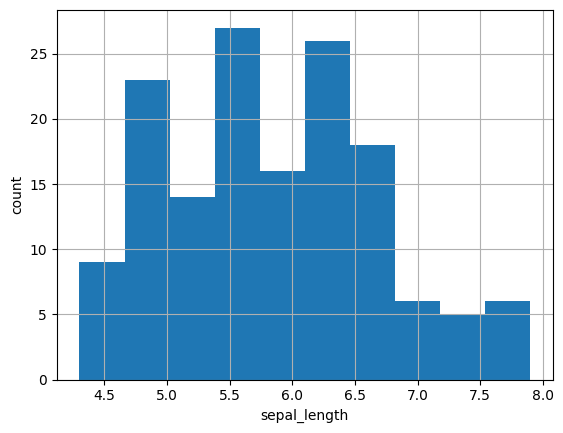

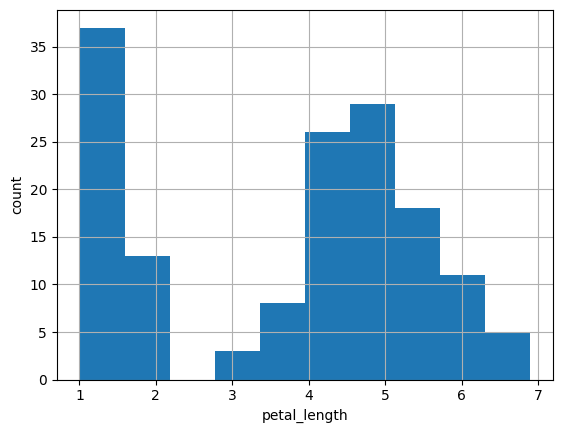

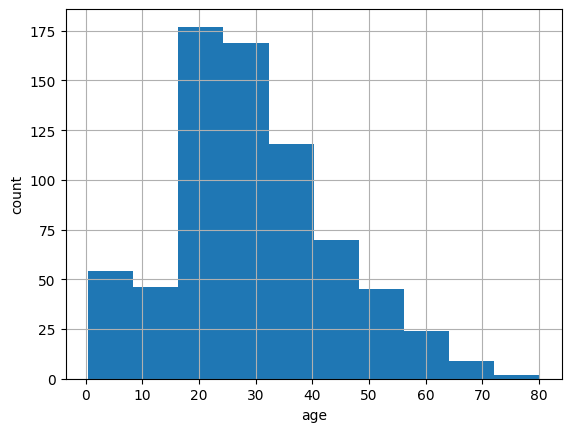

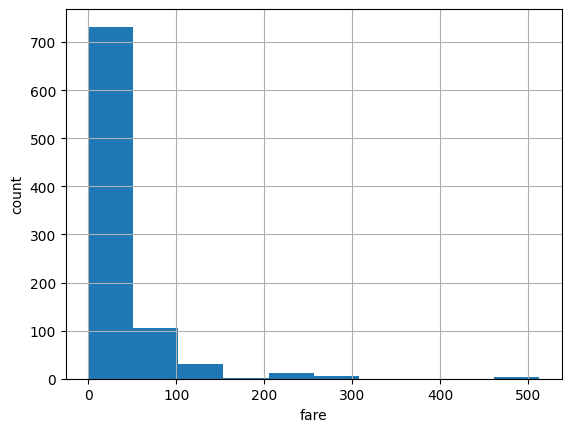

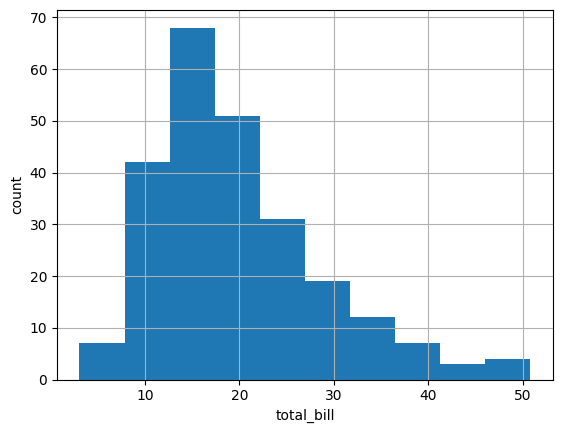

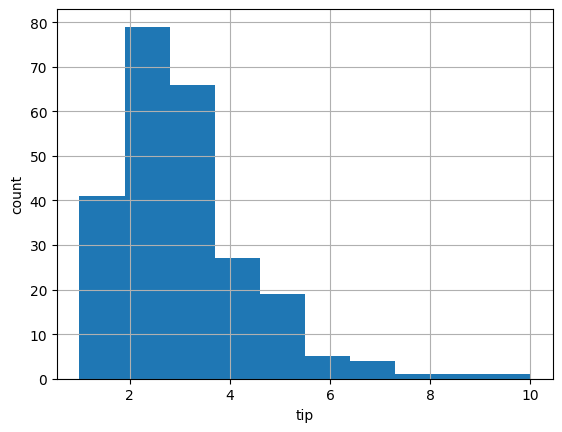

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

df_iris = sns.load_dataset("iris")
df_titanic = sns.load_dataset("titanic")
df_tips = sns.load_dataset("tips")

df_iris["sepal_length"].hist()
plt.xlabel("sepal_length")
plt.ylabel("count")
plt.show()

df_iris["petal_length"].hist()
plt.xlabel("petal_length")
plt.ylabel("count")
plt.show()

df_titanic["age"].hist()
plt.xlabel("age")
plt.ylabel("count")
plt.show()

df_titanic["fare"].hist()
plt.xlabel("fare")
plt.ylabel("count")
plt.show()

df_tips["total_bill"].hist()
plt.xlabel("total_bill")
plt.ylabel("count")
plt.show()

df_tips["tip"].hist()
plt.xlabel("tip")
plt.ylabel("count")
plt.show()


In [ ]:
#TASK 7

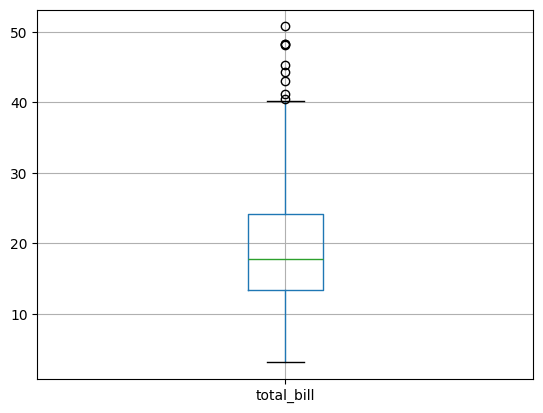

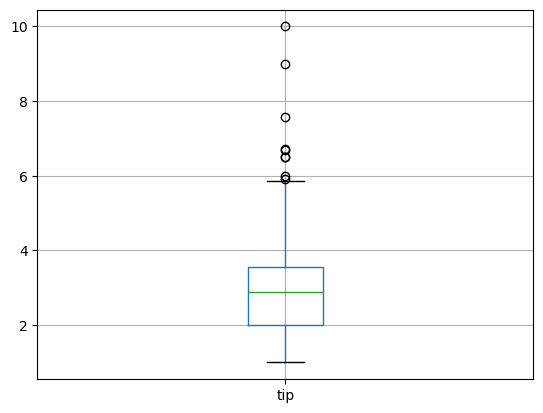

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

q1_bill = df["total_bill"].quantile(0.25)
q3_bill = df["total_bill"].quantile(0.75)
iqr_bill = q3_bill - q1_bill

lower_bill = q1_bill - 1.5 * iqr_bill
upper_bill = q3_bill + 1.5 * iqr_bill

out_bill = df[(df["total_bill"] < lower_bill) | (df["total_bill"] > upper_bill)]

q1_tip = df["tip"].quantile(0.25)
q3_tip = df["tip"].quantile(0.75)
iqr_tip = q3_tip - q1_tip

lower_tip = q1_tip - 1.5 * iqr_tip
upper_tip = q3_tip + 1.5 * iqr_tip

out_tip = df[(df["tip"] < lower_tip) | (df["tip"] > upper_tip)]

len(out_bill)
len(out_tip)

df.boxplot(column=["total_bill"])
plt.show()

df.boxplot(column=["tip"])
plt.show()


In [ ]:
#TASK 8

In [11]:
import seaborn as sns

df = sns.load_dataset("tips")

q1_bill = df["total_bill"].quantile(0.25)
q3_bill = df["total_bill"].quantile(0.75)
iqr_bill = q3_bill - q1_bill

q1_tip = df["tip"].quantile(0.25)
q3_tip = df["tip"].quantile(0.75)
iqr_tip = q3_tip - q1_tip

lower_bill = q1_bill - 1.5 * iqr_bill
upper_bill = q3_bill + 1.5 * iqr_bill

lower_tip = q1_tip - 1.5 * iqr_tip
upper_tip = q3_tip + 1.5 * iqr_tip

df.shape

df_clean = df[
    (df["total_bill"] >= lower_bill) & (df["total_bill"] <= upper_bill) &
    (df["tip"] >= lower_tip) & (df["tip"] <= upper_tip)
]

df_clean.shape


(229, 7)

In [ ]:
#TASK 9

In [12]:
import seaborn as sns

df = sns.load_dataset("tips")

before_mean = df[["total_bill", "tip"]].mean()
before_median = df[["total_bill", "tip"]].median()
before_std = df[["total_bill", "tip"]].std()

q1_bill = df["total_bill"].quantile(0.25)
q3_bill = df["total_bill"].quantile(0.75)
iqr_bill = q3_bill - q1_bill

q1_tip = df["tip"].quantile(0.25)
q3_tip = df["tip"].quantile(0.75)
iqr_tip = q3_tip - q1_tip

df_clean = df[
    (df["total_bill"] >= q1_bill - 1.5 * iqr_bill) &
    (df["total_bill"] <= q3_bill + 1.5 * iqr_bill) &
    (df["tip"] >= q1_tip - 1.5 * iqr_tip) &
    (df["tip"] <= q3_tip + 1.5 * iqr_tip)
]

after_mean = df_clean[["total_bill", "tip"]].mean()
after_median = df_clean[["total_bill", "tip"]].median()
after_std = df_clean[["total_bill", "tip"]].std()

before_mean, after_mean
before_median, after_median
before_std, after_std


(total_bill    8.902412
 tip           1.383638
 dtype: float64,
 total_bill    7.212792
 tip           1.085224
 dtype: float64)

In [ ]:
#TASK 10

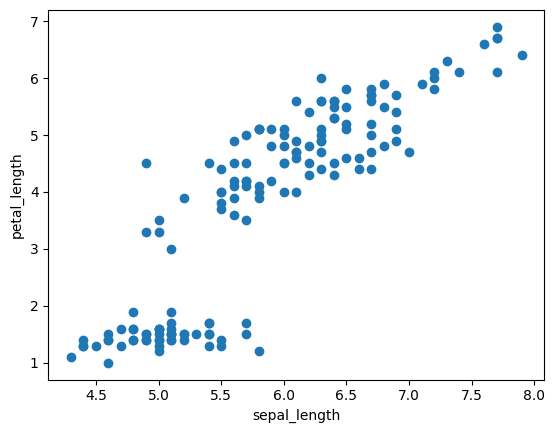

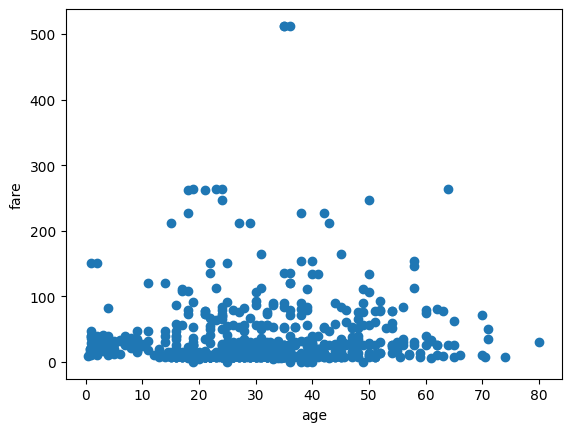

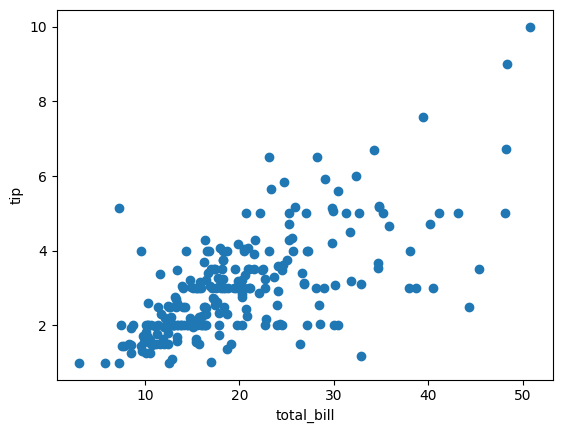

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df_iris = sns.load_dataset("iris")
df_titanic = sns.load_dataset("titanic")
df_tips = sns.load_dataset("tips")

plt.scatter(df_iris["sepal_length"], df_iris["petal_length"])
plt.xlabel("sepal_length")
plt.ylabel("petal_length")
plt.show()

plt.scatter(df_titanic["age"], df_titanic["fare"])
plt.xlabel("age")
plt.ylabel("fare")
plt.show()

plt.scatter(df_tips["total_bill"], df_tips["tip"])
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.show()


In [ ]:
#TASK 11

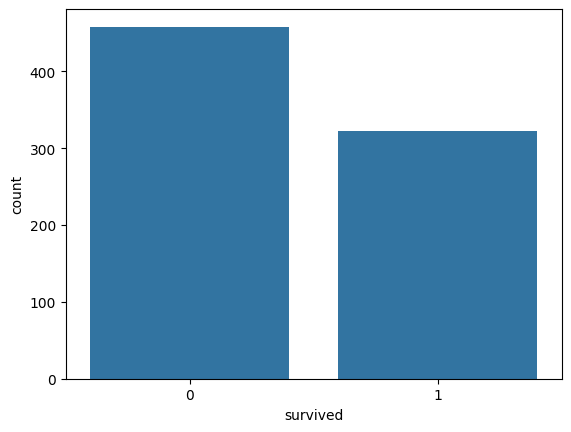

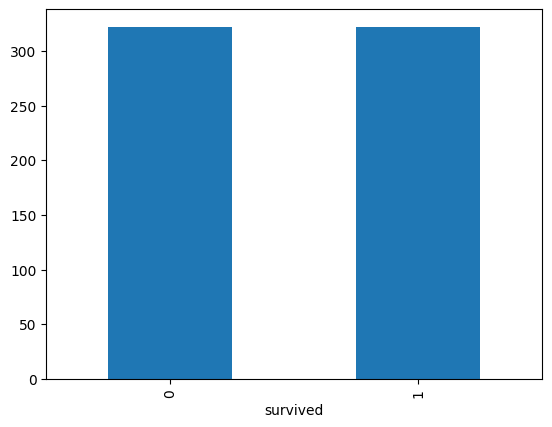

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = sns.load_dataset("titanic")

df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df = df.drop(columns=["deck"])
df = df.drop_duplicates()

df["survived"].value_counts()
df.shape

sns.countplot(x="survived", data=df)
plt.show()

df_0 = df[df["survived"] == 0]
df_1 = df[df["survived"] == 1]

df_0_sampled = df_0.sample(len(df_1), random_state=1)

df_balanced = pd.concat([df_0_sampled, df_1])

df_balanced["survived"].value_counts()
df_balanced.shape

df_balanced["survived"].value_counts().plot(kind="bar")
plt.show()


In [ ]:
#TASK 12 

In [17]:
# TASK 12 - Correlation Analysis and Feature Redundancy

# Iris Correlation
print("=== Iris Correlation Matrix ===")
iris_corr = iris.corr(numeric_only=True)
print(iris_corr)

plt.figure()
sns.heatmap(iris_corr, annot=True, cmap="coolwarm")
plt.title("Iris Correlation Heatmap")
plt.show()


# Titanic Correlation
print("\n=== Titanic Correlation Matrix ===")
titanic_corr = titanic.corr(numeric_only=True)
print(titanic_corr)

plt.figure()
sns.heatmap(titanic_corr, annot=True, cmap="coolwarm")
plt.title("Titanic Correlation Heatmap")
plt.show()


# Tips Correlation
print("\n=== Tips Correlation Matrix ===")
tips_corr = tips.corr(numeric_only=True)
print(tips_corr)

plt.figure()
sns.heatmap(tips_corr, annot=True, cmap="coolwarm")
plt.title("Tips Correlation Heatmap")
plt.show()


(petal_length  petal_width    0.962865
 dtype: float64,
 sibsp  parch    0.414838
 dtype: float64,
 tip  total_bill    0.675734
 dtype: float64)

In [ ]:
#TASK 13

In [16]:
summary = [
    "Missing values were found in multiple datasets",
    "Mean imputation was applied to numerical columns",
    "Mode imputation was applied to categorical columns",
    "High-missing column deck was removed",
    "Duplicate records were detected and removed",
    "Outliers were identified using IQR method",
    "Outliers were removed to stabilize statistics",
    "Class imbalance was found in Titanic dataset",
    "Random undersampling was applied to balance classes",
    "Datasets are now suitable for ML modeling"
]

for i in summary:
    print("-", i)


- Missing values were found in multiple datasets
- Mean imputation was applied to numerical columns
- Mode imputation was applied to categorical columns
- High-missing column deck was removed
- Duplicate records were detected and removed
- Outliers were identified using IQR method
- Outliers were removed to stabilize statistics
- Class imbalance was found in Titanic dataset
- Random undersampling was applied to balance classes
- Datasets are now suitable for ML modeling
